In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


In [2]:
titanic = sns.load_dataset('titanic')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


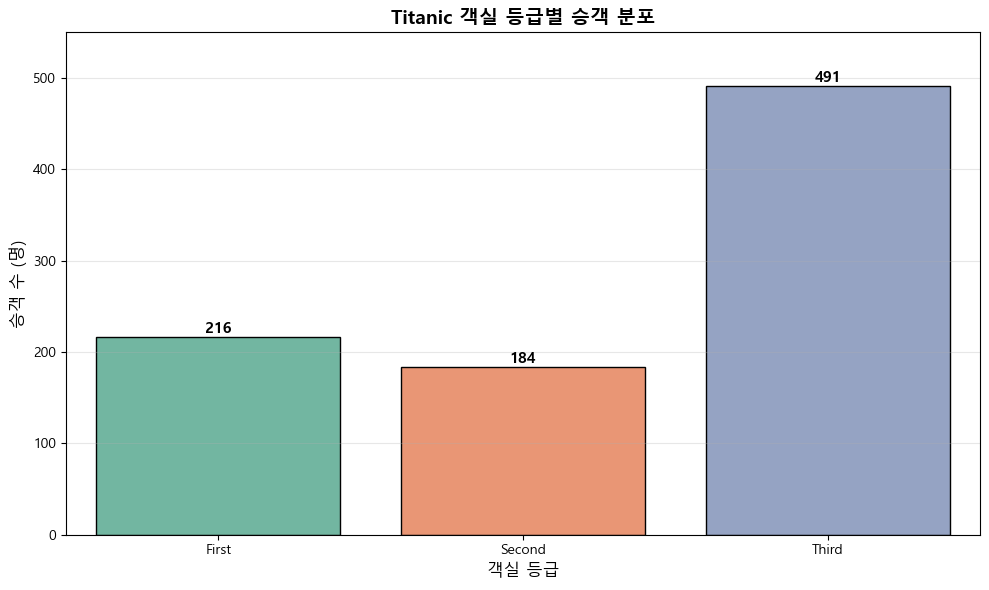

In [24]:
fig, ax = plt.subplots(figsize=(10,6))

sns.countplot(data=titanic,x='class',ax=ax, palette='Set2',edgecolor='black')

for container in ax.containers:
    ax.bar_label(container, fontsize=11,fontweight='bold')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('승객 수 (명)', fontsize=12)
ax.set_title('Titanic 객실 등급별 승객 분포', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0,550)
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_5492\4121620991.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])


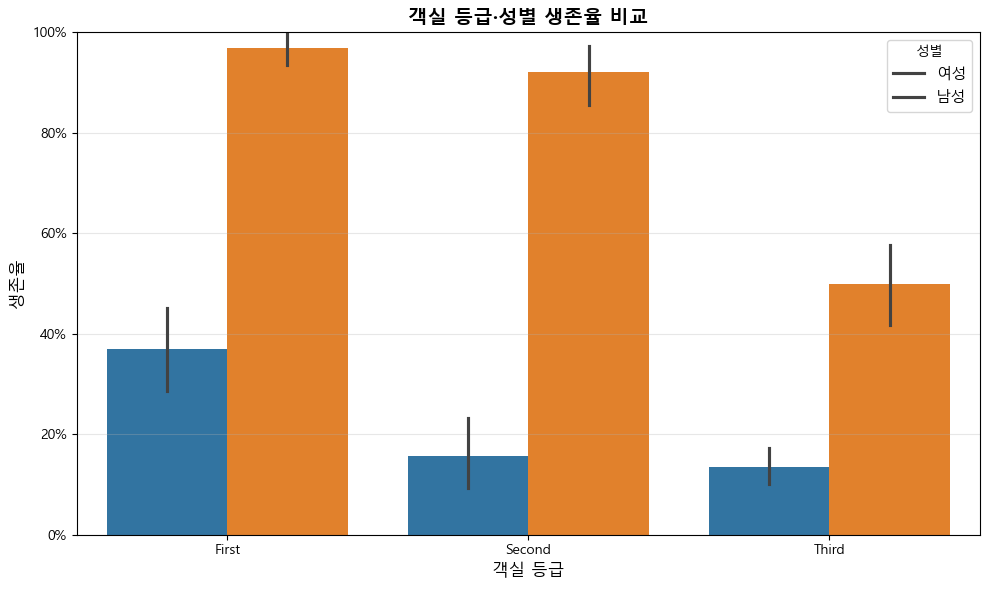

class   sex   
First   female    0.968085
        male      0.368852
Second  female    0.921053
        male      0.157407
Third   female    0.500000
        male      0.135447
Name: survived, dtype: float64


C:\Users\Playdata\AppData\Local\Temp\ipykernel_5492\4121620991.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()


In [17]:
# 성별, 등급별 생존율

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=titanic, x='class', y='survived', hue='sex')

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('생존율', fontsize=12)
ax.set_title('객실 등급·성별 생존율 비교', fontsize=14, fontweight='bold')
ax.legend(title='성별', labels=['여성', '남성'], fontsize=11)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3, axis='y')

ax.set_yticklabels([f'{int(y*100)}%' for y in ax.get_yticks()])

plt.tight_layout()
plt.show()

survival_by_class_sex = titanic.groupby(['class', 'sex'])['survived'].mean()
print(survival_by_class_sex)

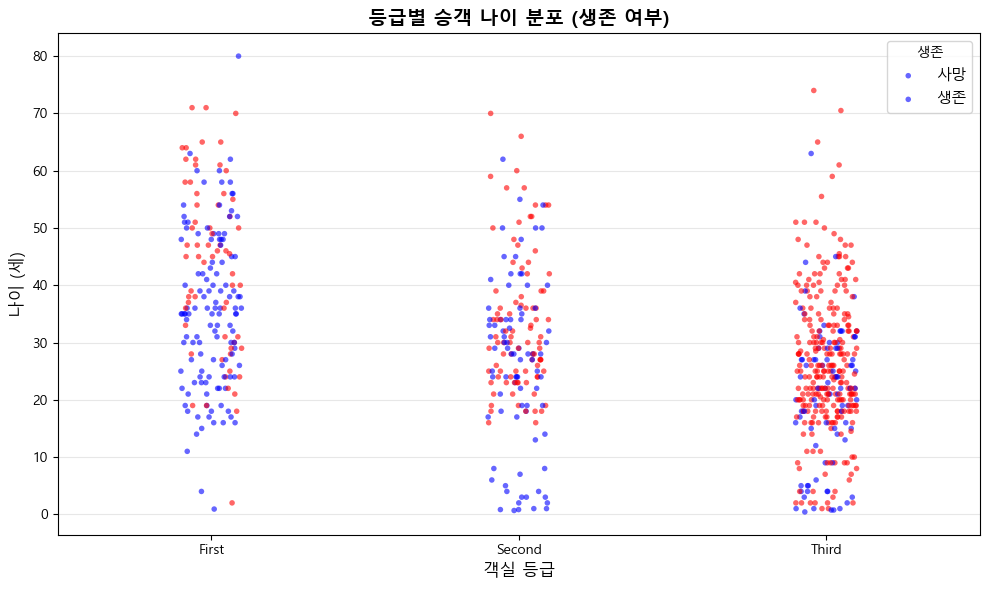

In [20]:
ig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=titanic,x='class',y='age',hue='survived', ax=ax,
              palette={0:'red',1:'blue'}, alpha=0.6, size=4)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('나이 (세)', fontsize=12)
ax.set_title('등급별 승객 나이 분포 (생존 여부)', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


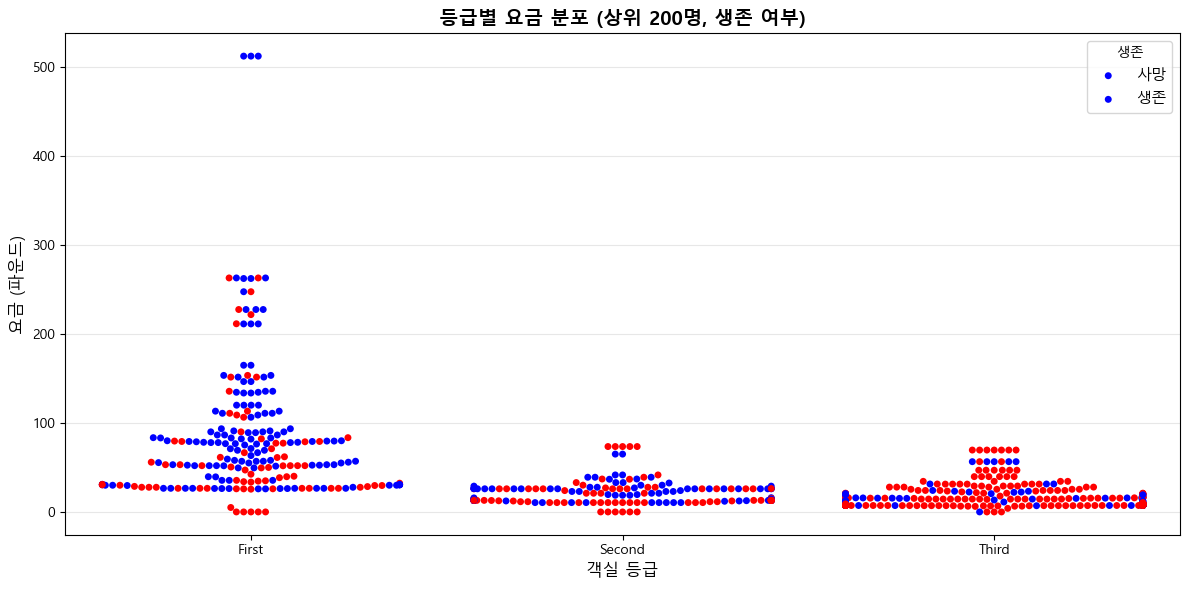

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

# 요금 상위 200명만 (가독성 위해)
titanic_fare = titanic.nlargest(200, 'fare')

# Swarmplot 생성
sns.swarmplot(data=titanic, x='class',y='fare',hue='survived', ax=ax,
              edgecolor='black', palette={0:'red',1:'blue'}, size=5)

ax.set_xlabel('객실 등급', fontsize=12)
ax.set_ylabel('요금 (파운드)', fontsize=12)
ax.set_title('등급별 요금 분포 (상위 200명, 생존 여부)', fontsize=14, fontweight='bold')
ax.legend(title='생존', labels=['사망', '생존'], fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
